In [1]:
from pathlib import Path

# Untitled.ipynb nằm ngay trong THIS_STUDIO
ROOT = Path.cwd()
DATASET_PATH = ROOT / "data" / "word_wheel_water_meter"
DATA_YAML_PATH = DATASET_PATH / "data.yaml"
RUNS_DIR = ROOT / "runs" / "segment"

yaml_content = f"""
path: {DATASET_PATH.resolve().as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: reading_region
"""

DATA_YAML_PATH.write_text(yaml_content, encoding="utf-8")

print(f"ROOT: {ROOT}")
print(f"Dataset: {DATASET_PATH}")
print(f"data.yaml: {DATA_YAML_PATH}")


ROOT: /teamspace/studios/this_studio
Dataset: /teamspace/studios/this_studio/data/word_wheel_water_meter
data.yaml: /teamspace/studios/this_studio/data/word_wheel_water_meter/data.yaml


In [2]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
!pip install ultralytics
from ultralytics import YOLO
import pandas as pd
import random

# DATASET_PATH đã được khai báo ở cell phía trên

split = ["train", "val", "test"]

for s in split:
    img_dir = DATASET_PATH / "images" / s
    label_dir = DATASET_PATH / "labels" / s
    
    print(f"Số lượng ảnh trong tập {s}: {len(list(img_dir.glob('*.*')))}")
    print(f"Số lượng label trong tập {s}: {len(list(label_dir.glob('*.txt')))}")

Số lượng ảnh trong tập train: 29436
Số lượng label trong tập train: 29436
Số lượng ảnh trong tập val: 3270
Số lượng label trong tập val: 3270
Số lượng ảnh trong tập test: 13391
Số lượng label trong tập test: 13391


# 2. Trực quan hóa dữ liệu với polygon

/teamspace/studios/this_studio/data/word_wheel_water_meter/labels/train/train0.txt


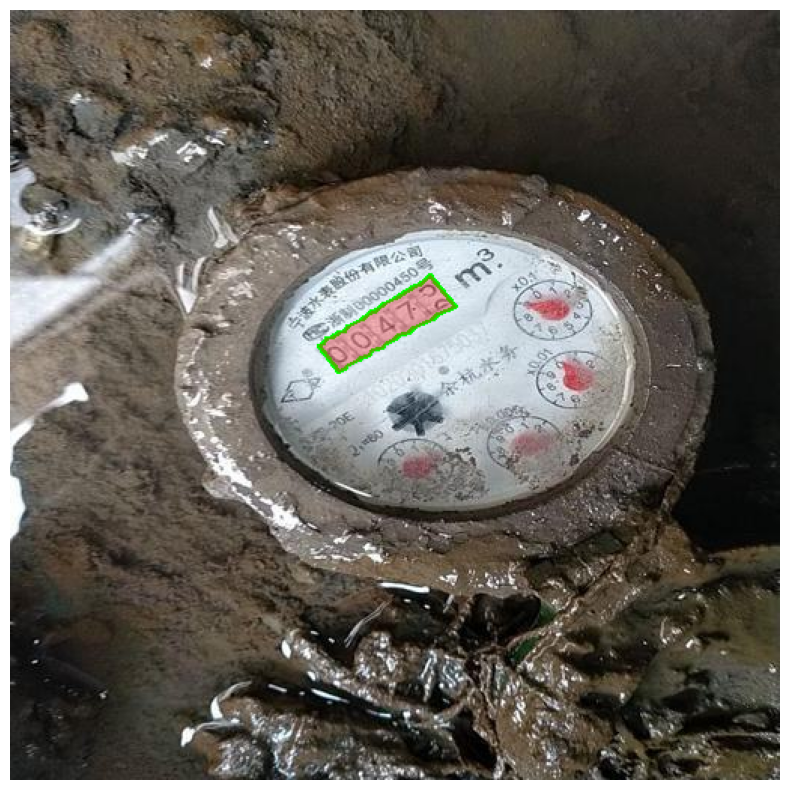

In [3]:
img_path = DATASET_PATH / "images" / "train"
label_path = DATASET_PATH / "labels" / "train"

img_dir = list(img_path.glob("*.*"))

img_file = img_dir[0]
img_0 = cv2.imread(str(img_file))
img_rgb = cv2.cvtColor(img_0, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

label_file = label_path / f"{img_file.stem}.txt"
print(label_file)

with open(label_file, "r") as f:
    lines = f.readlines()

for line in lines:
        parts = list(map(float, line.strip().split()))
        if len(parts) > 1:
            class_id = int(parts[0])
            coords = parts[1:]
            
            points = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                points.append([x, y])
            
            pts = np.array(points, np.int32).reshape((-1, 1, 2))
            
            cv2.polylines(img_rgb, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
            
            overlay = img_rgb.copy()
            cv2.fillPoly(overlay, [pts], color=(255, 0, 0)) # Màu đỏ mờ
            img_rgb = cv2.addWeighted(overlay, 0.3, img_rgb, 0.7, 0)

plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# 3. Huấn luyện mô hình

In [4]:
model = YOLO("runs/segment/train-2/weights/last.pt")

results = model.train(
    data=str(DATA_YAML_PATH), 
    epochs=25, 
    batch=16, 
    workers=4, 


    # --- Tối ưu hóa lỗi Background (Bkg) ---
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.1,   
    
    # --- Phép biến đổi khác ---
    scale=0.3,
    fliplr=0.5,
    flipud=0.5,
    erasing=0.05,
    copy_paste=0,
    close_mosaic=15,
    
    # --- Hyperparameters ---
    warmup_epochs=5,
    weight_decay=0.0005,
    patience=30,
    lr0=0.001,
    lrf=0.1,
    cos_lr=True,
    optimizer="AdamW",
    project=str(RUNS_DIR),
    name="train"
)

# Ultralytics có thể tạo train, train2, train3... nếu thư mục đã tồn tại.
# Lấy đúng thư mục của lần train vừa chạy để các cell sau không bị sai path.
TRAIN_DIR = Path(model.trainer.save_dir)
BEST_MODEL_PATH = TRAIN_DIR / "weights" / "best.pt"
print(f"Training output: {TRAIN_DIR}")
print(f"Best model: {BEST_MODEL_PATH}")


New https://pypi.org/project/ultralytics/8.4.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.135 🚀 Python-3.12.11 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/teamspace/studios/this_studio/data/word_wheel_water_meter/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.05, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4

# 4. Trực quan hóa kết quả


📊 Training Results:
   🎯 mAP50: 0.9950
   🎯 mAP50-95: 0.8517
   🎯 Precision: 1.0000
   🎯 Recall: 1.0000
   📦 Box loss: 0.6281
   🏷️  Cls loss: 0.2188
   🎯 DFL loss: 0.8611


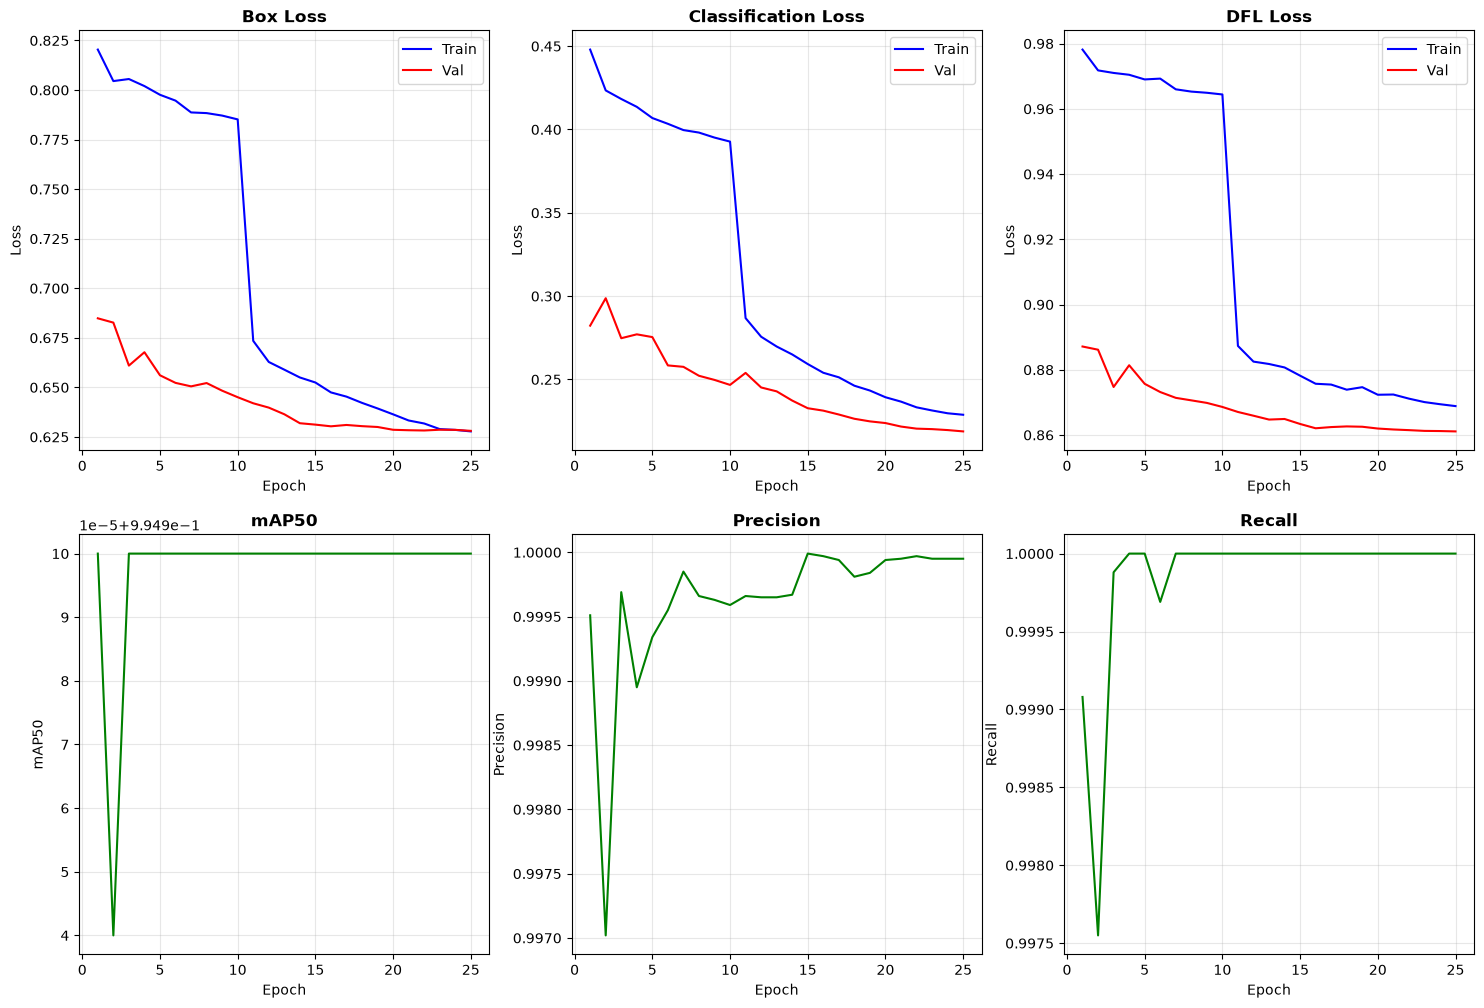

In [5]:
def visualize_training_loss(results_path):
    results_csv = Path(results_path) / "results.csv"
    df = pd.read_csv(results_csv)
    last_row = df.iloc[-1]
    final_metrics = {
            'mAP50': last_row.get('metrics/mAP50(B)', 0),
            'mAP50_95': last_row.get('metrics/mAP50-95(B)', 0),
            'precision': last_row.get('metrics/precision(B)', 0),
            'recall': last_row.get('metrics/recall(B)', 0),
            'box_loss': last_row.get('val/box_loss', 0),
            'cls_loss': last_row.get('val/cls_loss', 0),
            'dfl_loss': last_row.get('val/dfl_loss', 0)
        }
    
    # In kết quả cuối cùng
    print(f"\n📊 Training Results:")
    print(f"   🎯 mAP50: {final_metrics['mAP50']:.4f}")
    print(f"   🎯 mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"   🎯 Precision: {final_metrics['precision']:.4f}")
    print(f"   🎯 Recall: {final_metrics['recall']:.4f}")
    print(f"   📦 Box loss: {final_metrics['box_loss']:.4f}")
    print(f"   🏷️  Cls loss: {final_metrics['cls_loss']:.4f}")
    print(f"   🎯 DFL loss: {final_metrics['dfl_loss']:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    metrics = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
        ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss')
    ]
    for idx, (train_metric, val_metric, title) in enumerate(metrics):
        ax = axes[0, idx]
        if train_metric in df.columns:
            ax.plot(df['epoch'], df[train_metric], label='Train', color='blue')
        if val_metric in df.columns:
            ax.plot(df['epoch'], df[val_metric], label='Val', color='red')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    metric_plots = [
        ('metrics/mAP50(B)', 'mAP50'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall')
    ]
    
    for idx, (metric, title) in enumerate(metric_plots):
        ax = axes[1, idx]
        if metric in df.columns:
            ax.plot(df['epoch'], df[metric], color='green')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(title)
            ax.grid(True, alpha=0.3)
    plt.show()
    return final_metrics

final_metrics = visualize_training_loss(TRAIN_DIR)

# 5. Trực quan hóa biểu đồ confusion matrix và ROC

--- Confusion Matrix ---


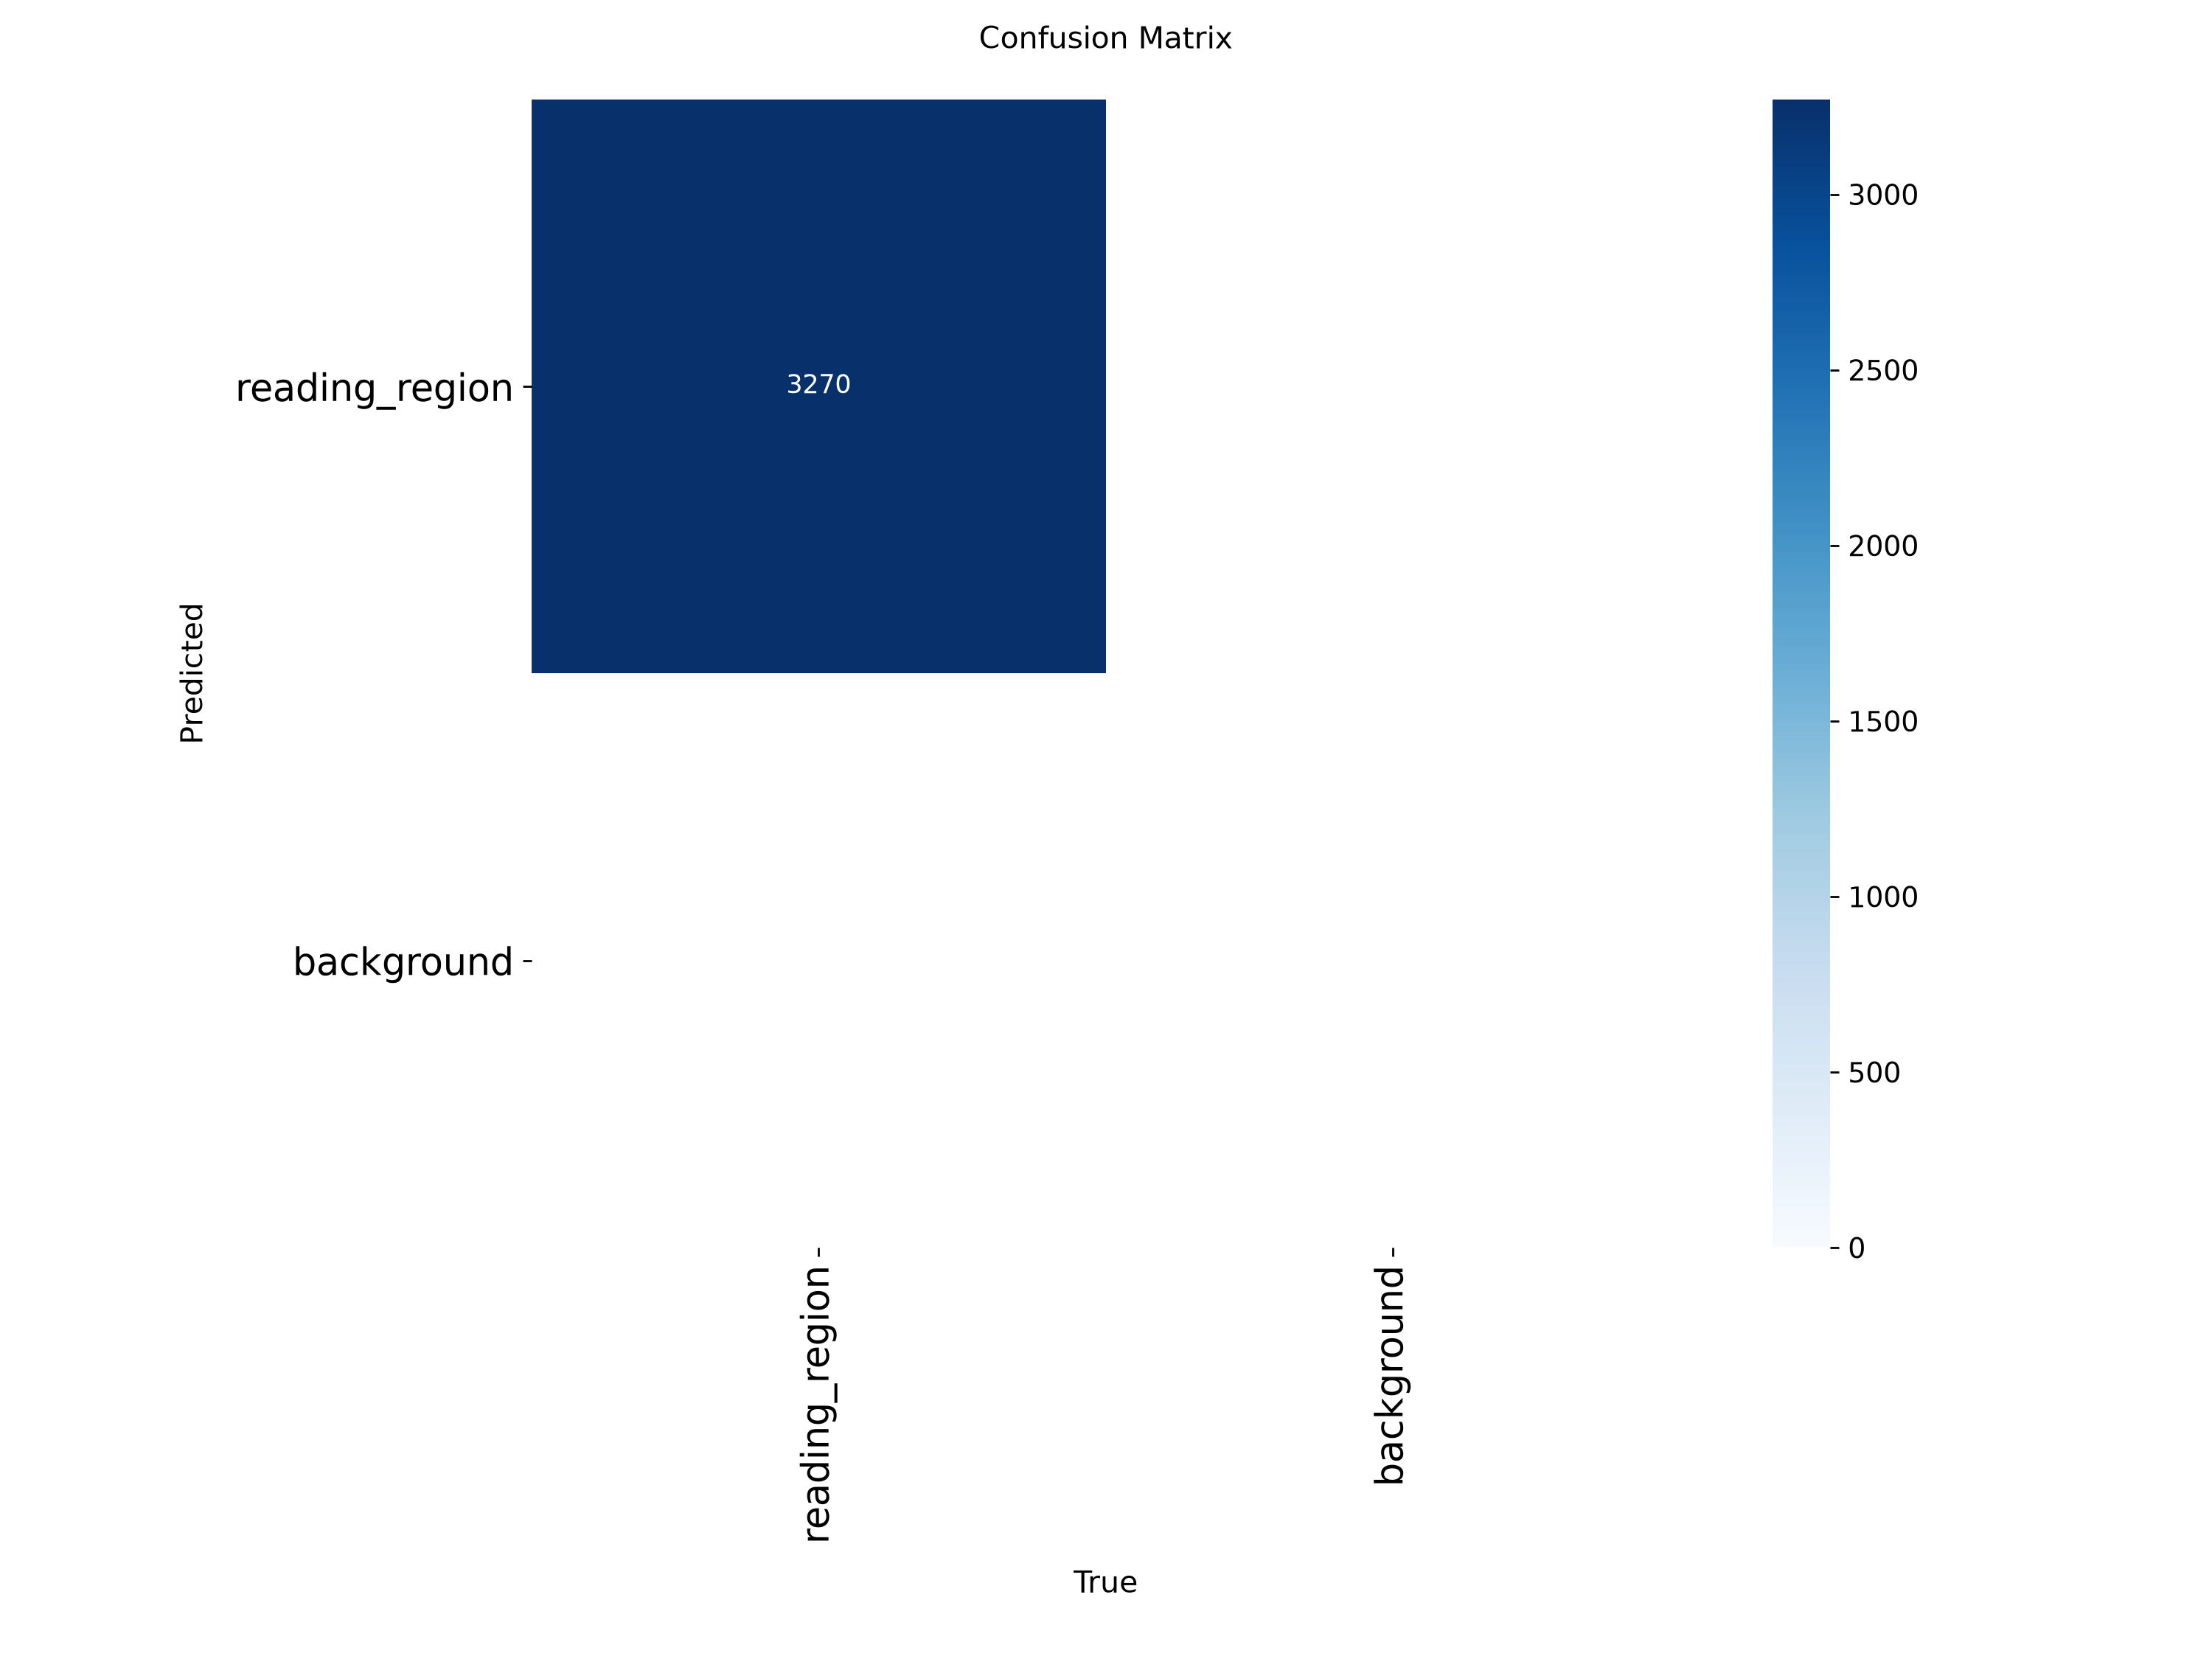

--- PR Curve ---


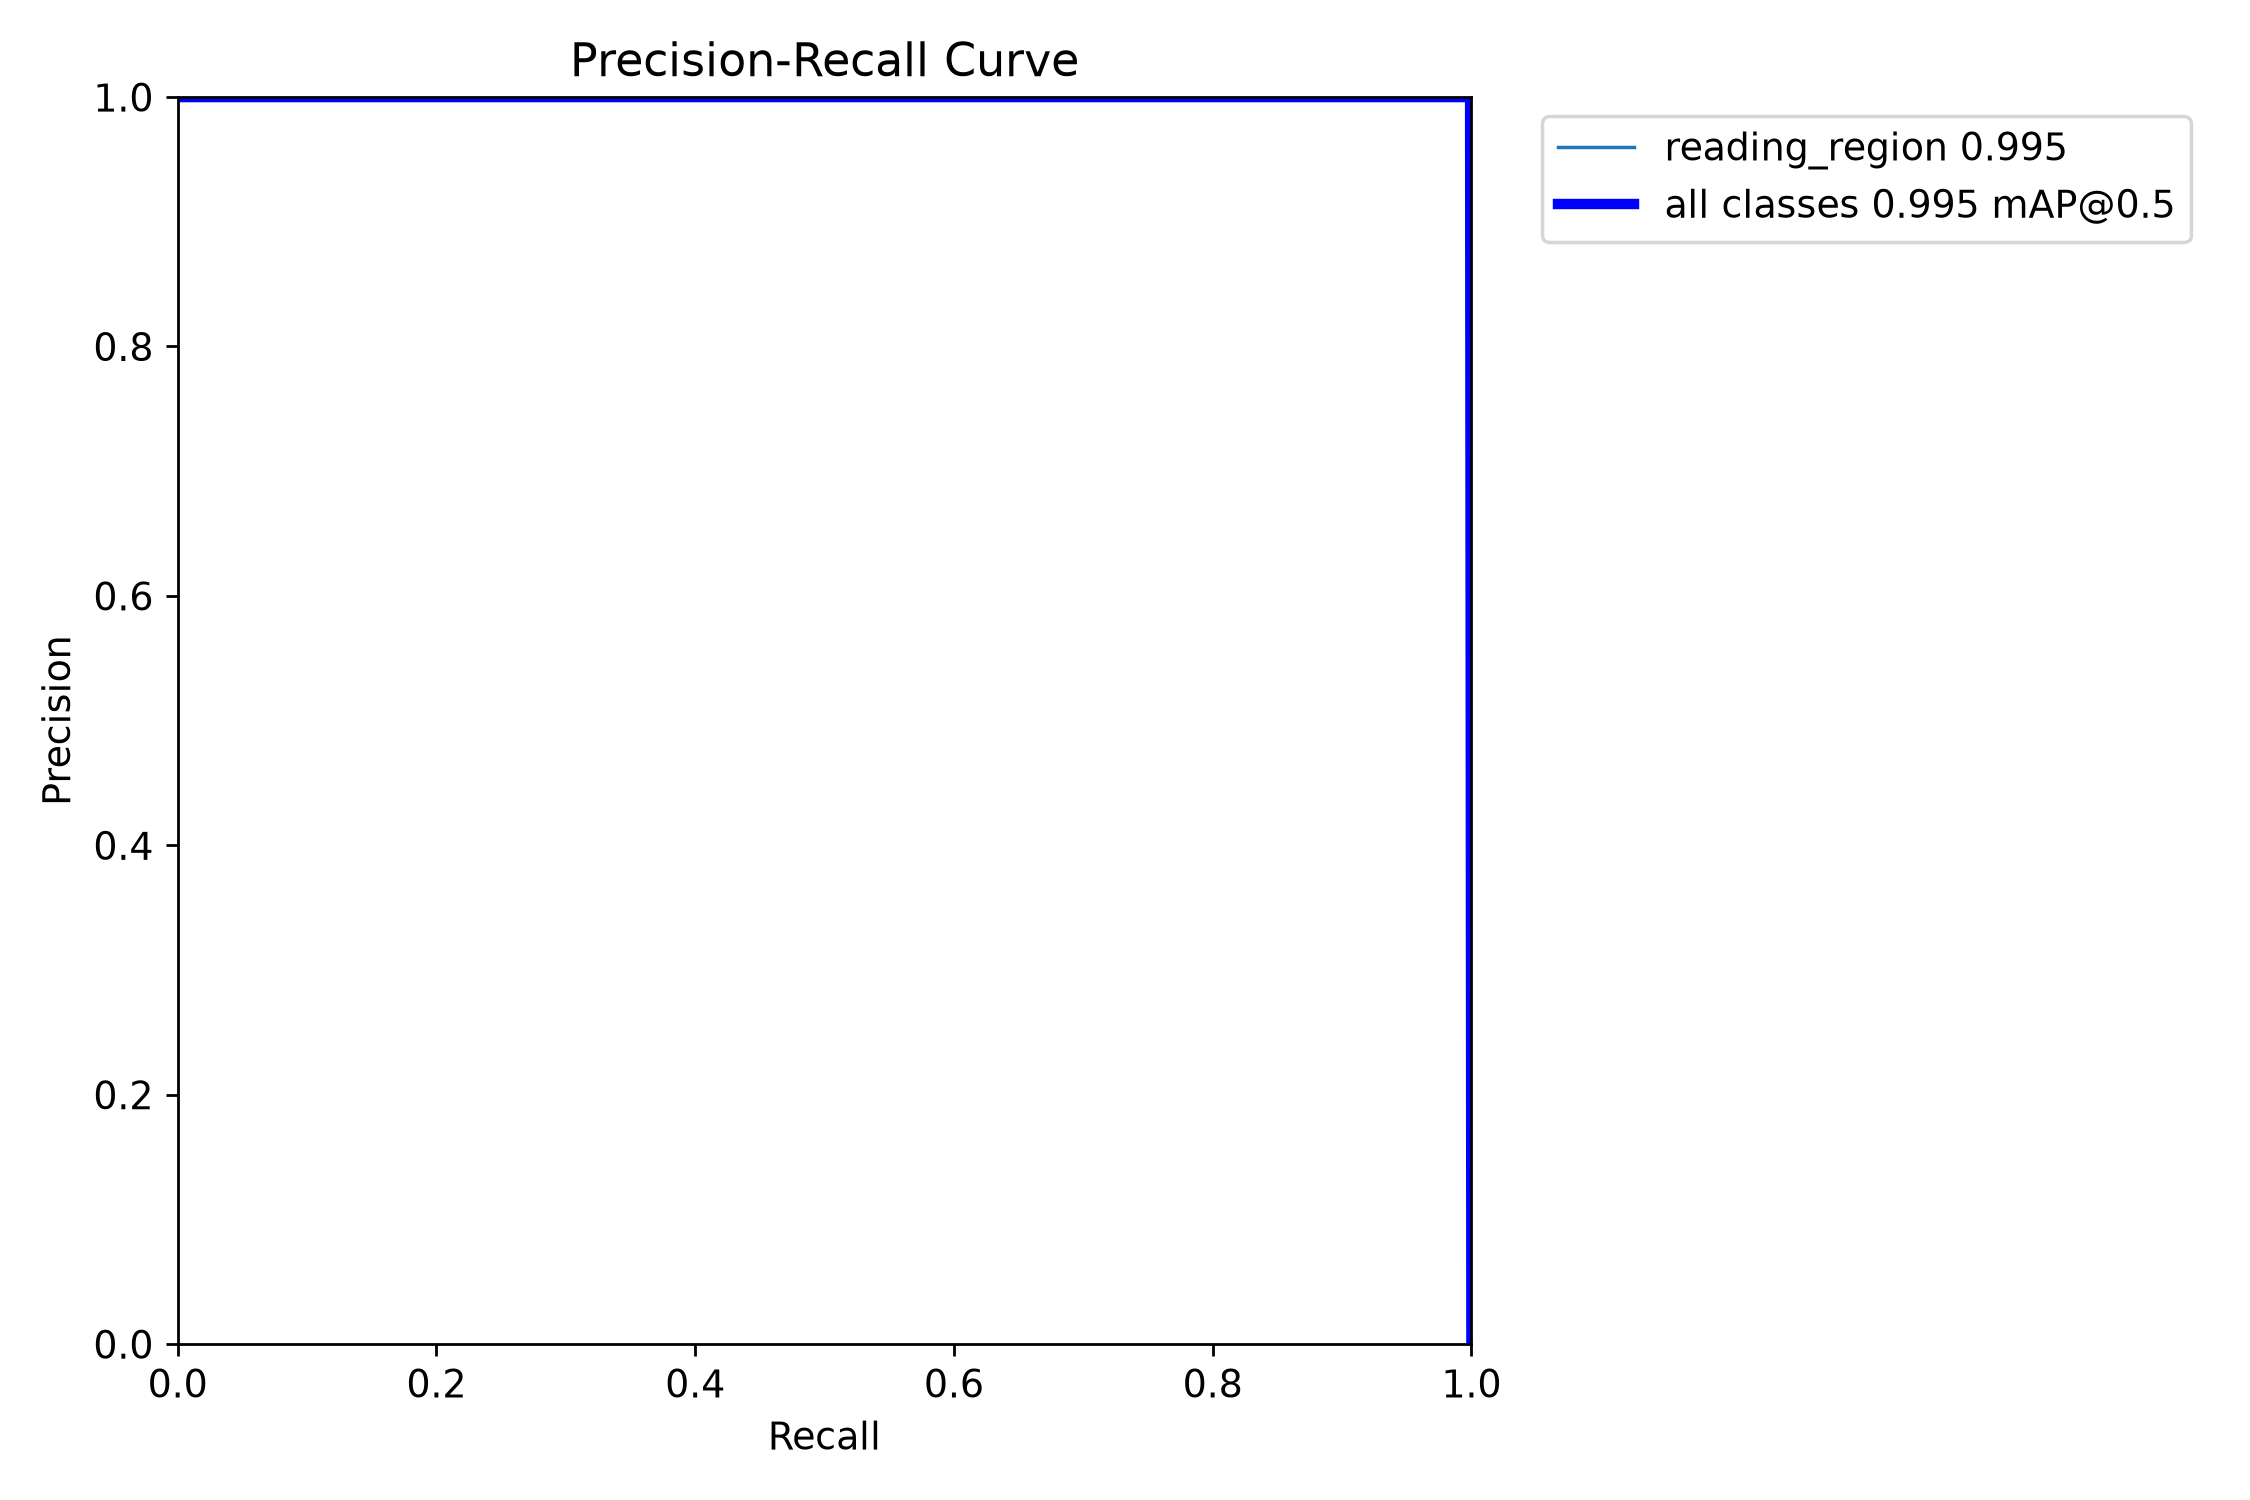

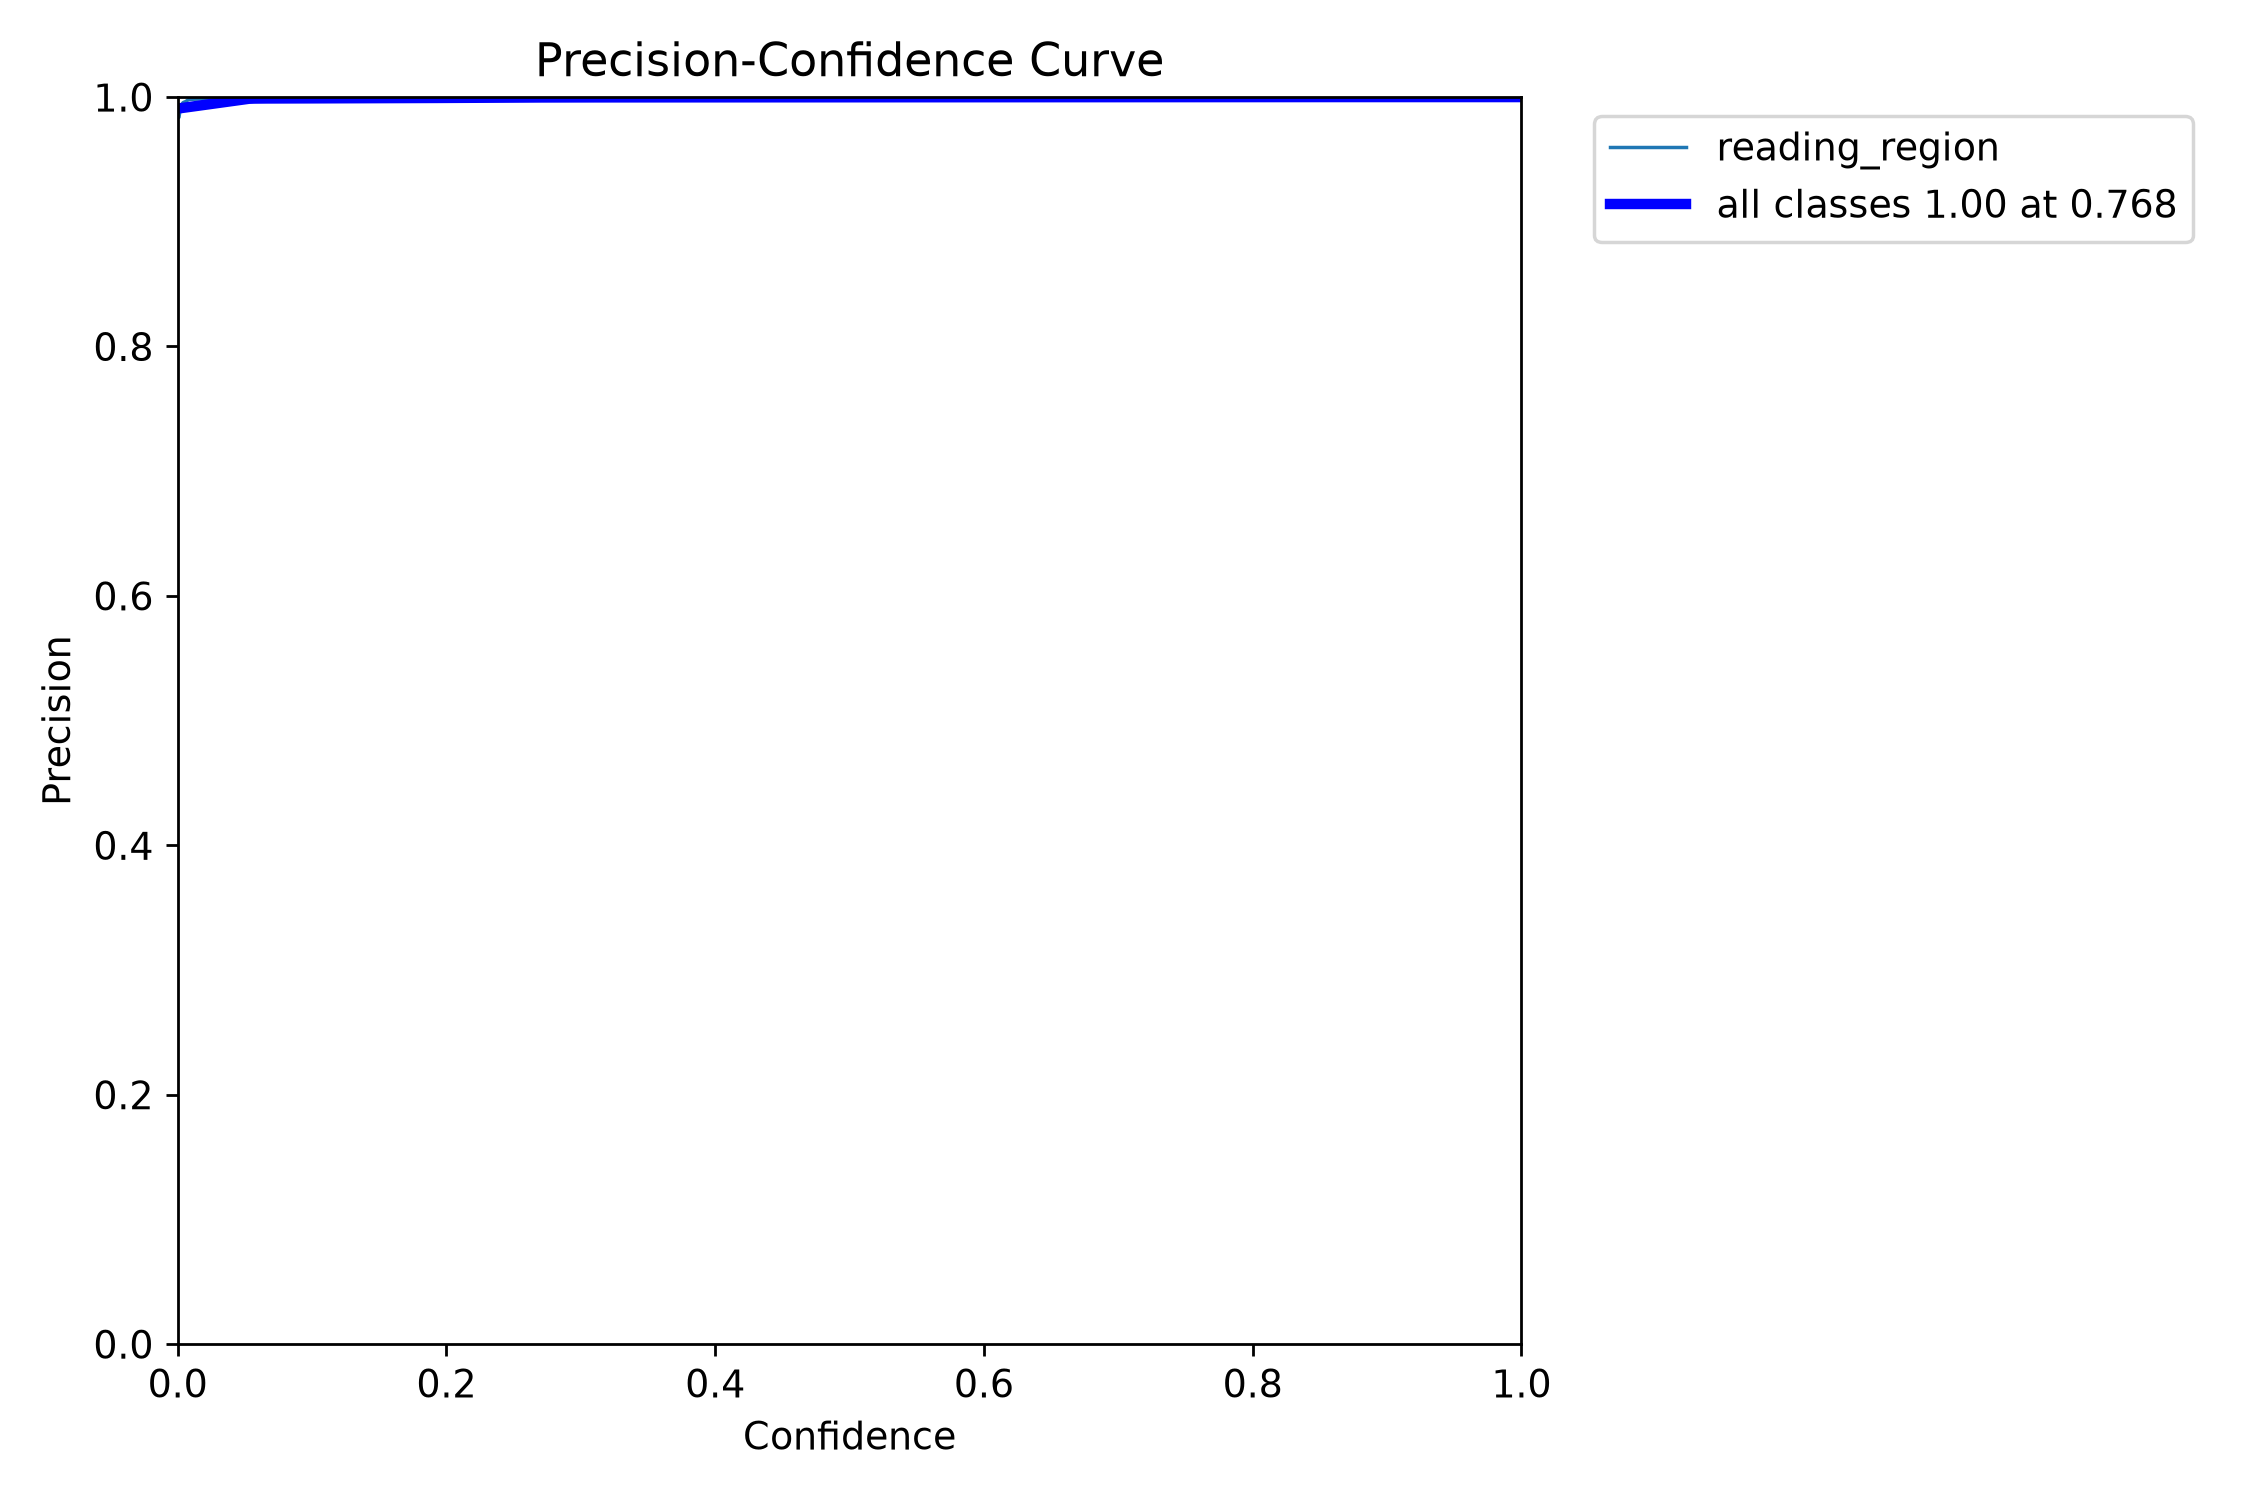

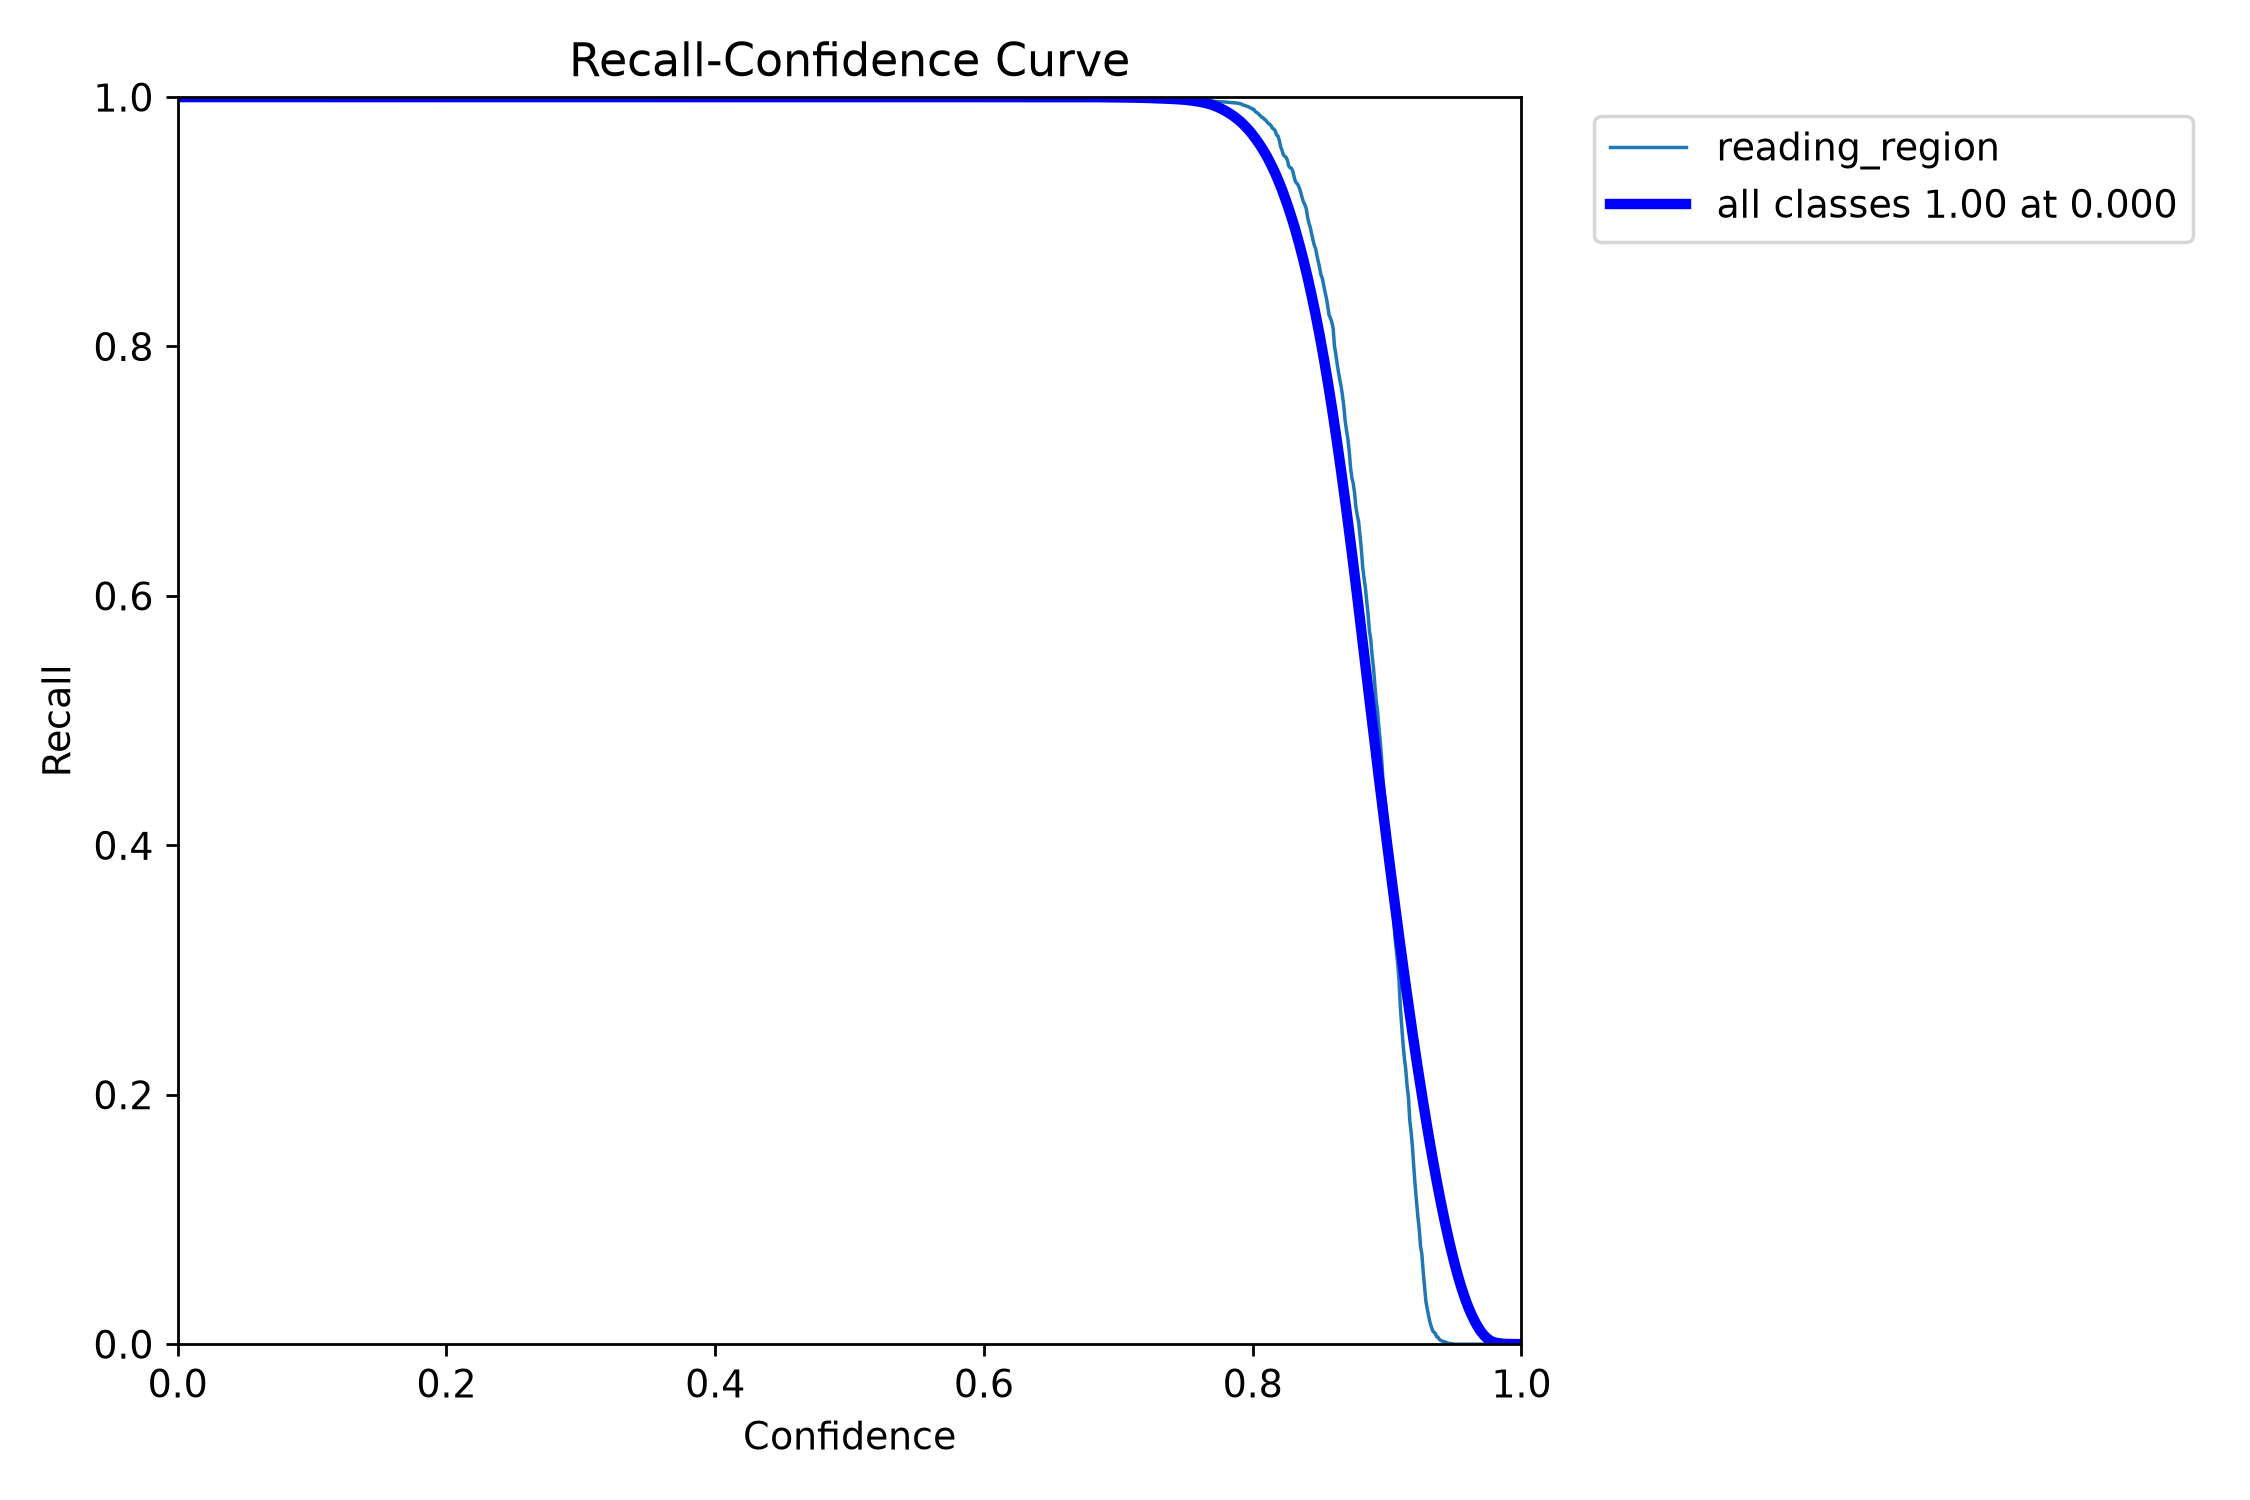

--- Loss & Metrics (Results) ---


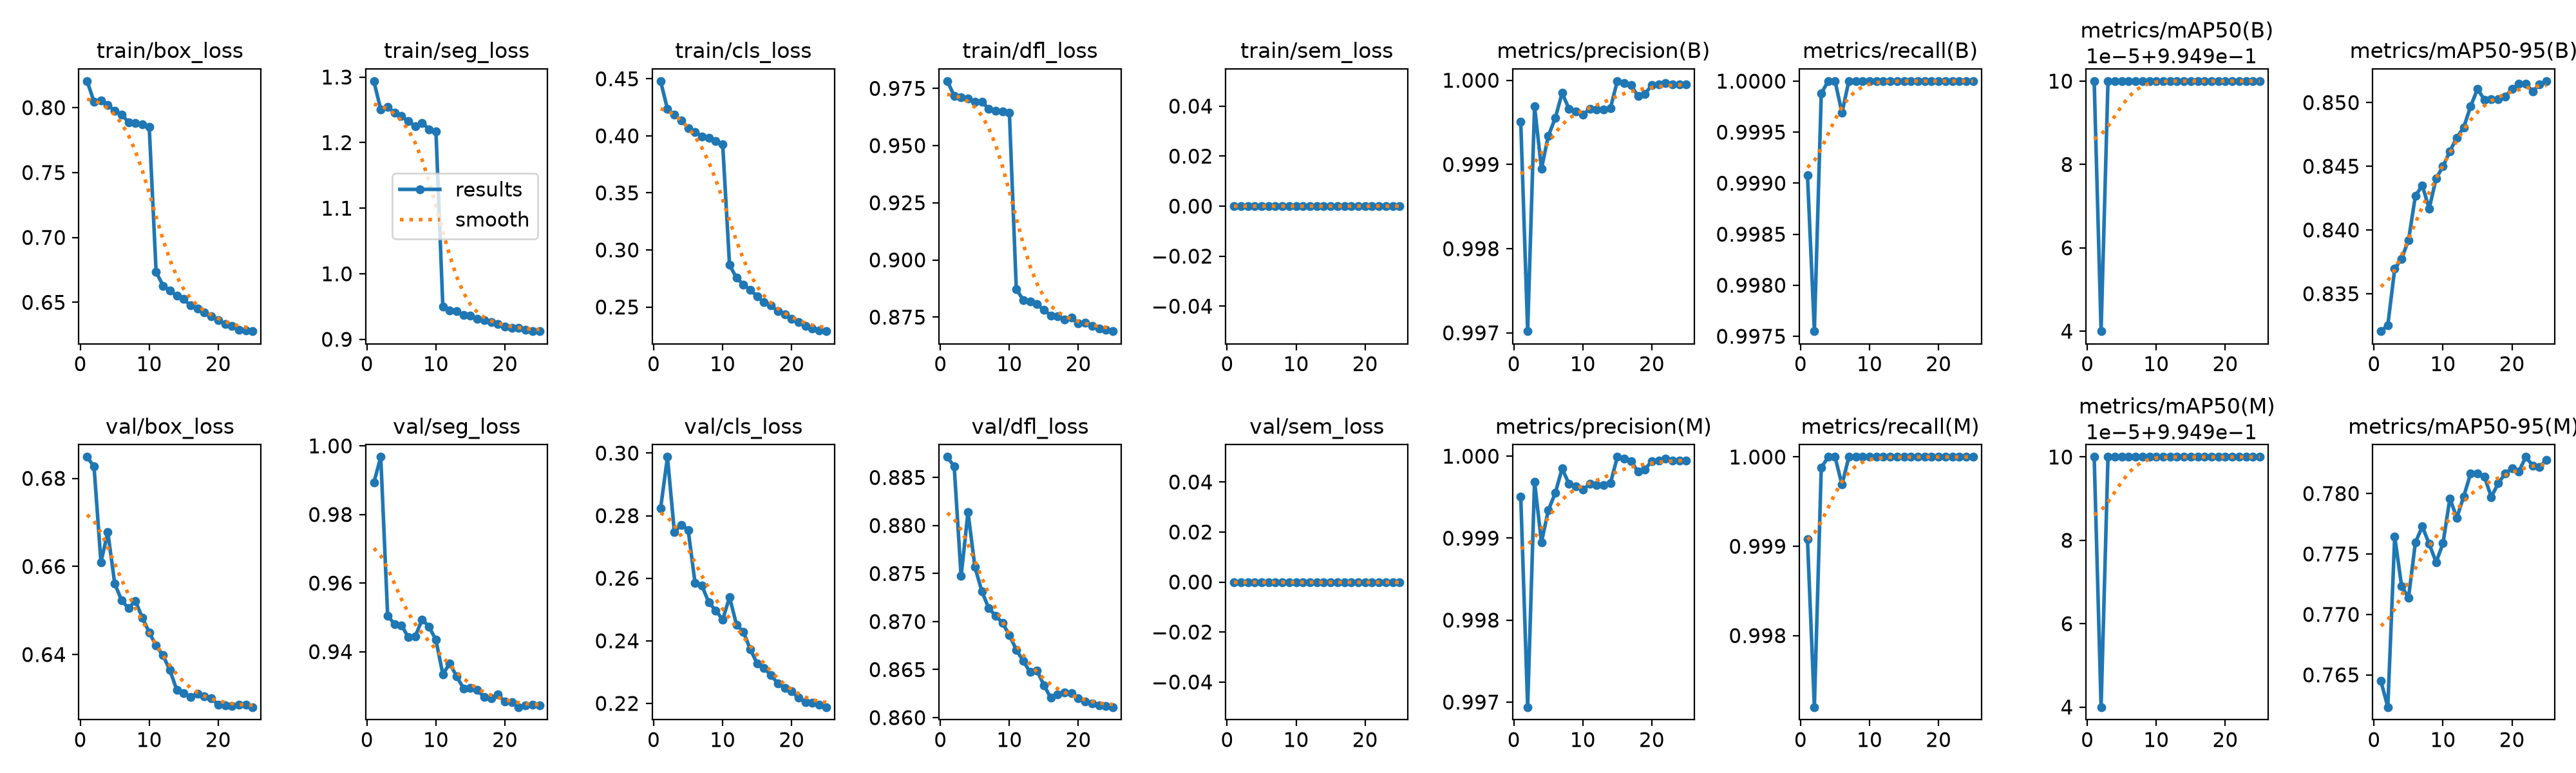

In [6]:
from IPython.display import Image, display

# Thư mục kết quả của đúng lần train vừa chạy
folder_path = TRAIN_DIR

print("--- Confusion Matrix ---")
display(Image(filename=str(folder_path / "confusion_matrix.png"), width=1000))
print("--- PR Curve ---")
display(Image(filename=str(folder_path / "BoxPR_curve.png"), width=1000))
display(Image(filename=str(folder_path / "BoxP_curve.png"), width=1000))
display(Image(filename=str(folder_path / "BoxR_curve.png"), width=1000))

print("--- Loss & Metrics (Results) ---")
display(Image(filename=str(folder_path / "results.png"), width=1000))


# 6. Dự đoán

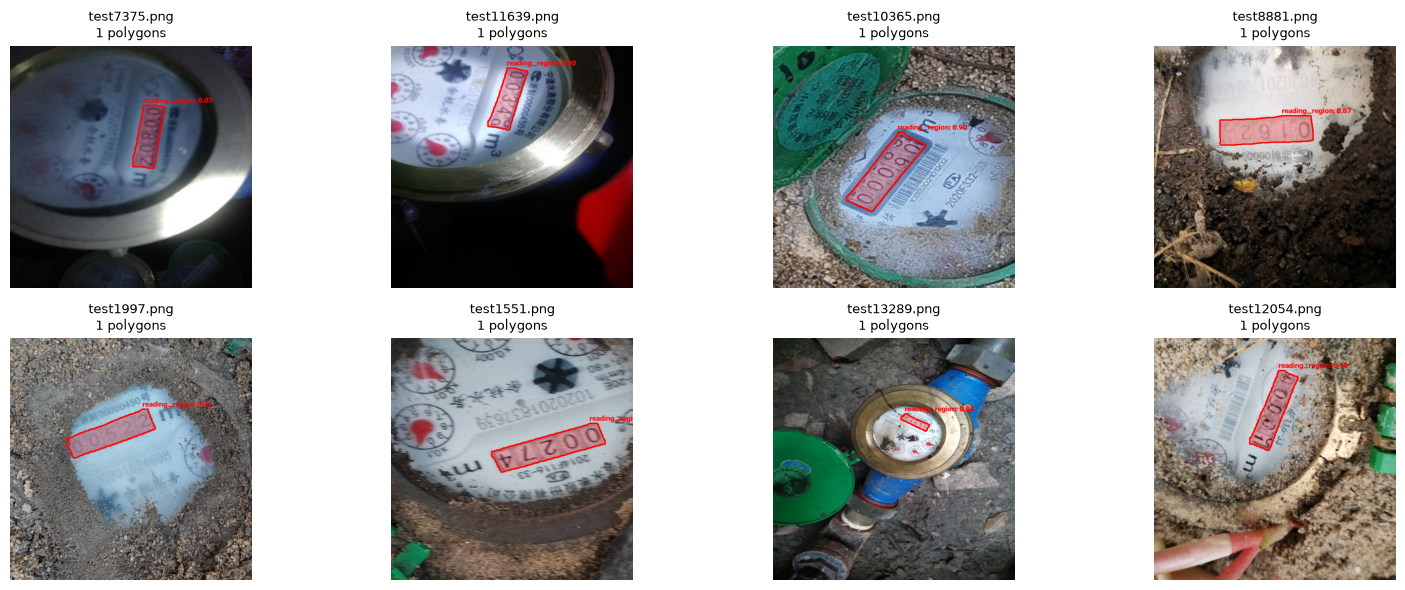


Detection Summary:
   Images: 8
   Polygons: 8
   Average per image: 1.0
   Average confidence: 0.888
   Max confidence: 0.934

Class Distribution:
   reading_region: 8


In [7]:
from collections import Counter

def predict_and_visualize(model_path, test_images_dir, num_samples=8, conf_threshold=0.5):
    model = YOLO(model_path)
    test_path = Path(test_images_dir)
    image_extensions = {".jpg", ".jpeg", ".png"}
    image_files = sorted(
        p for p in test_path.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    )

    if not image_files:
        raise FileNotFoundError(f"Không tìm thấy ảnh trong: {test_path}")

    random.seed(42)
    image_files = random.sample(image_files, min(num_samples, len(image_files)))

    cols = min(4, len(image_files))
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.atleast_1d(axes).flatten()

    total_detections = 0
    class_counts = Counter()
    confidences = []

    for idx, img_path in enumerate(image_files):
        ax = axes[idx]
        img = cv2.imread(str(img_path))

        if img is None:
            ax.set_title(f"Không đọc được: {img_path.name}")
            ax.axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = model.predict(str(img_path), conf=conf_threshold, verbose=False)
        result = results[0]
        detections = 0

        if result.masks is not None and result.boxes is not None:
            polygons = result.masks.xy
            boxes = result.boxes

            for polygon, box in zip(polygons, boxes):
                detections += 1
                total_detections += 1

                cls_id = int(box.cls[0].cpu().item())
                conf = float(box.conf[0].cpu().item())
                confidences.append(conf)
                class_counts[cls_id] += 1

                color = tuple(
                    int(channel * 255)
                    for channel in plt.cm.hsv(cls_id / max(len(model.names), 1))[:3]
                )
                polygon = np.asarray(polygon, dtype=np.int32).reshape((-1, 1, 2))

                overlay = img_rgb.copy()
                cv2.fillPoly(overlay, [polygon], color=color)
                img_rgb = cv2.addWeighted(overlay, 0.25, img_rgb, 0.75, 0)
                cv2.polylines(
                    img_rgb,
                    [polygon],
                    isClosed=True,
                    color=color,
                    thickness=2,
                )

                class_name = model.names.get(cls_id, str(cls_id))
                x_text, y_text = polygon[0, 0]
                cv2.putText(
                    img_rgb,
                    f"{class_name}: {conf:.2f}",
                    (int(x_text), max(int(y_text) - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2,
                    cv2.LINE_AA,
                )

        ax.imshow(img_rgb)
        ax.set_title(f"{img_path.name}\n{detections} polygons", fontsize=9)
        ax.axis("off")

    for idx in range(len(image_files), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

    print("\nDetection Summary:")
    print(f"   Images: {len(image_files)}")
    print(f"   Polygons: {total_detections}")
    print(f"   Average per image: {total_detections / len(image_files):.1f}")
    print(
        f"   Average confidence: {np.mean(confidences):.3f}"
        if confidences else "   Average confidence: N/A"
    )
    print(
        f"   Max confidence: {np.max(confidences):.3f}"
        if confidences else "   Max confidence: N/A"
    )

    print("\nClass Distribution:")
    for cls_id, count in class_counts.most_common():
        class_name = model.names.get(cls_id, str(cls_id))
        print(f"   {class_name}: {count}")

    return {
        "total_detections": total_detections,
        "class_counts": dict(class_counts),
        "avg_confidence": float(np.mean(confidences)) if confidences else 0.0,
    }

prediction_results = predict_and_visualize(
    model_path=str(BEST_MODEL_PATH),
    test_images_dir=str(DATASET_PATH / "images" / "test"),
    num_samples=8,
    conf_threshold=0.5,
)

# 7. Đánh giá mô hình trên tập test

In [8]:
model = YOLO(str(BEST_MODEL_PATH))  

def evaluate_model(model):    
    # Chạy validation
    metrics = model.val(data=str(data_yaml_path), split='test')

    # 1. Lấy F1-score (thường lấy tại index của confidence threshold ~0.5)
    # metrics.box.f1 trả về mảng F1 cho mỗi class
    f1_scores = metrics.box.f1
    mean_f1 = f1_scores.mean()

    # 2. Tính toán FPS
    # speed_stats bao gồm: 'preprocess', 'inference', 'loss', 'postprocess'
    speed = metrics.speed
    latency_per_img = speed['preprocess'] + speed['inference'] + speed['postprocess']
    fps = 1000 / latency_per_img

    print(f"\n📊 Evaluation Results:")
    print(f"   🎯 Mean F1-Score: {mean_f1:.4f}")
    print(f"   ⚡ FPS: {fps:.2f} ({latency_per_img:.2f} ms/ảnh)")

    # 3. In F1 per Class
    print(f"\n📈 F1 per Class:")
    # Sử dụng metrics.names để đảm bảo mapping chính xác
    for i, class_id in enumerate(metrics.ap_class_index):
        class_name = model.names[class_id]
        print(f"   🔹 {class_name}: {f1_scores[i]:.4f}")

    return {
        "mean_f1": mean_f1,
        "fps": fps
    }
data_yaml_path = DATA_YAML_PATH
evaluate_model(model)

Ultralytics 8.4.135 🚀 Python-3.12.11 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 88.8±35.2 MB/s, size: 53.0 KB)
val: Scanning /teamspace/studios/this_studio/data/word_wheel_water_meter/labels/test... 13391 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13391/13391 1.2Kit/s 11.2s0.1s
val: New cache created: /teamspace/studios/this_studio/data/word_wheel_water_meter/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 837/837 5.7it/s 2:260.2ss
                   all      13391      13391          1          1      0.995      0.813          1          1      0.995      0.743
Speed: 1.0ms preprocess, 4.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /teamspace/studios/this_studio/runs/segment/val

📊 Evaluatio

{'mean_f1': np.float64(0.9997257870036881), 'fps': 143.40200015270236}